# WPŁYW UWARUNKOWANIA MACIERZY INTERPOLACYJNEJ

Przyjrzymy się, jak trzy różne bazy wielomianowe:

1. **Baza naturalna (Vandermonde)** — $1, x, x^2, \\ldots, x^n$
2. **Interpolacja Lagrange'a** — bazy $L_k(x) = \\prod_{j\\neq k} \\frac{x-x_j}{x_k-x_j}$
3. **Interpolacja Newtona** — bazy $N_k(x) = \\prod_{j=0}^{k-1}(x-x_j)$

radzą sobie numerycznie przy rosnącej liczbie węzłów.

Wszystkie trzy metody powinny dać ten sam wynik analityczny, ale przy rosnącym stopniu wielomianu zjawiska numeryczne mogą się różnie objawiać.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def BaseInterpol(x_nodes, y_nodes, xx_eval):
    """Baza naturalna (Vandermonde) — np.polyfit/polyval."""
    degree = len(x_nodes) - 1
    coeffs = np.polyfit(x_nodes, y_nodes, degree)
    yy = np.polyval(coeffs, xx_eval)
    return yy

def LagrangeInterpol(x_nodes, y_nodes, xx_eval):
    """Interpolacja Lagrange'a."""
    yy = np.zeros_like(xx_eval, dtype=float)
    n = len(x_nodes)
    for i in range(n):
        L_i = np.ones_like(xx_eval)
        for j in range(n):
            if j != i:
                L_i *= (xx_eval - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        yy += y_nodes[i] * L_i
    return yy

def NewtonInterpol(x_nodes, y_nodes, xx_eval):
    """Interpolacja Newtona z ilorazami zagniezdzonymi."""
    n = len(x_nodes)
    dd = np.zeros((n, n))
    dd[:, 0] = y_nodes
    for j in range(1, n):
        for i in range(n - j):
            dd[i, j] = (dd[i + 1, j - 1] - dd[i, j - 1]) / (x_nodes[i + j] - x_nodes[i])
    yy = np.full_like(xx_eval, dd[0, 0], dtype=float)
    w = np.ones_like(xx_eval, dtype=float)
    for i in range(1, n):
        w *= (xx_eval - x_nodes[i - 1])
        yy += dd[0, i] * w
    return yy

In [2]:
# Oryginalny wielomian
wsp_oryg = np.array([1, 4, 2, 1, 1, 1]) * 1e-6

xx = np.linspace(-2, 2, 401)
yy_orig = np.polyval(wsp_oryg, xx)

print(f"Wspolczynniki oryginalne: {wsp_oryg}")
print(f"Stopien wielomianu: {len(wsp_oryg) - 1}")

Wspolczynniki oryginalne: [1.e-06 4.e-06 2.e-06 1.e-06 1.e-06 1.e-06]
Stopien wielomianu: 5


/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)


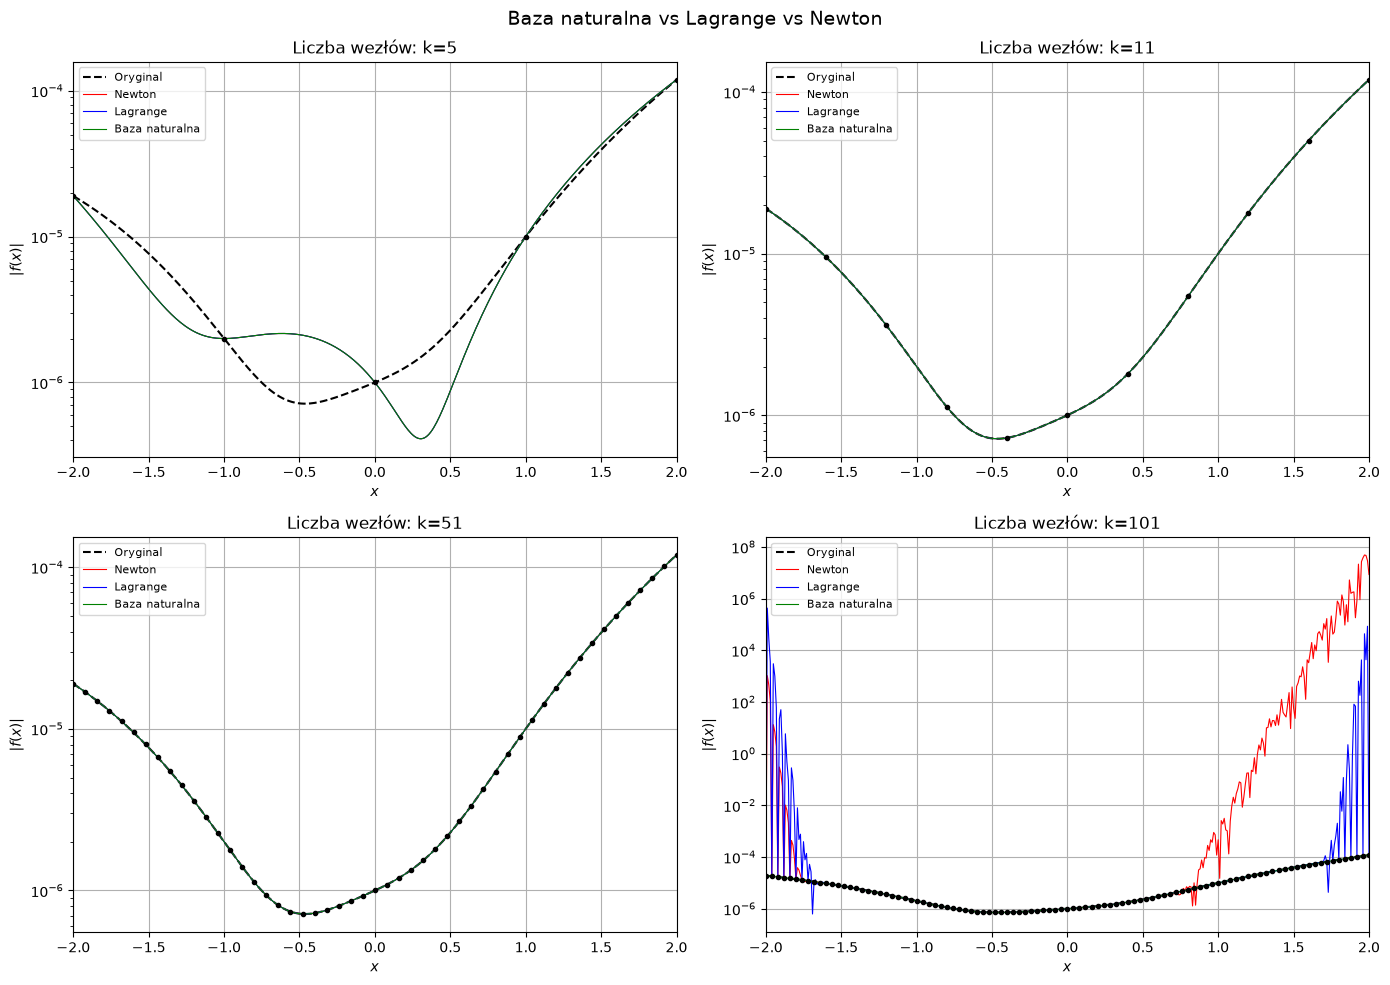

In [3]:
# Porównanie dla wybranych liczb wezłów
k_values = [5, 11, 51, 101]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, k in enumerate(k_values):
    ax = axes[idx]
    x_nodes = np.linspace(-2, 2, k)
    y_nodes = np.polyval(wsp_oryg, x_nodes)

    # Oblicz interpolacje
    yy_base = BaseInterpol(x_nodes, y_nodes, xx)
    yy_lag = LagrangeInterpol(x_nodes, y_nodes, xx)
    yy_newt = NewtonInterpol(x_nodes, y_nodes, xx)

    # Wykres
    ax.semilogy(xx, np.abs(yy_orig), 'k--', linewidth=1.5, label='Oryginal')
    ax.semilogy(xx, np.abs(yy_newt), 'r-', linewidth=0.8, label='Newton')
    ax.semilogy(xx, np.abs(yy_lag), 'b-', linewidth=0.8, label='Lagrange')
    ax.semilogy(xx, np.abs(yy_base), 'g-', linewidth=0.8, label='Baza naturalna')
    ax.semilogy(x_nodes, np.abs(y_nodes), 'ko', markersize=3)
    title_txt = f'Liczba wezł\u00f3w: k={k}'
    ax.set_title(title_txt)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$|f(x)|$')
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.set_xlim(-2, 2)

plt.suptitle('Baza naturalna vs Lagrange vs Newton', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit ma

/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit ma

/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)


/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)
/tmp/ipykernel_190540/1343939339.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_nodes, y_nodes, degree)


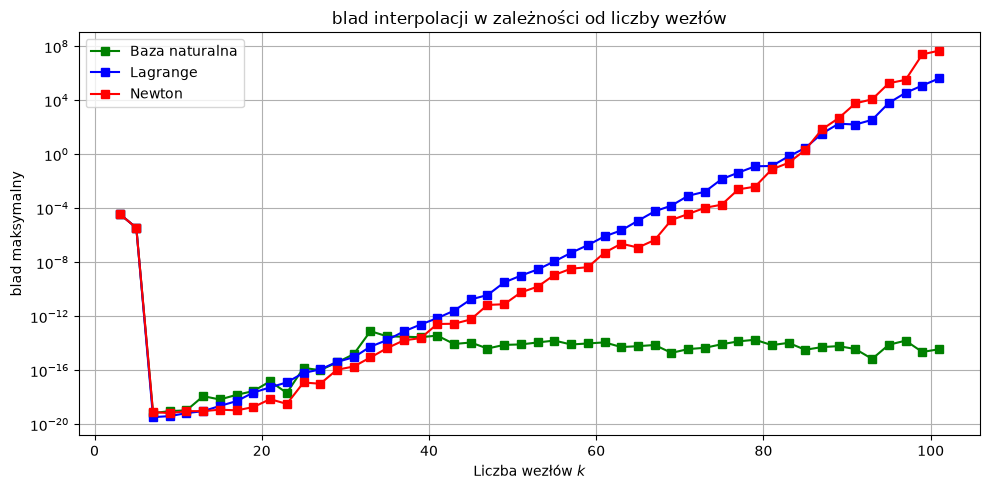

In [4]:
# blad maksymalny w zależności od liczby wezłów
k_range = list(range(3, 102, 2))
error_base = []
error_lag = []
error_newt = []

for k in k_range:
    x_nodes = np.linspace(-2, 2, k)
    y_nodes = np.polyval(wsp_oryg, x_nodes)

    yy_b = BaseInterpol(x_nodes, y_nodes, xx)
    error_base.append(np.max(np.abs(yy_b - yy_orig)))

    yy_l = LagrangeInterpol(x_nodes, y_nodes, xx)
    error_lag.append(np.max(np.abs(yy_l - yy_orig)))

    yy_n = NewtonInterpol(x_nodes, y_nodes, xx)
    error_newt.append(np.max(np.abs(yy_n - yy_orig)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(k_range, error_base, 'gs-', label='Baza naturalna')
ax.semilogy(k_range, error_lag, 'bs-', label='Lagrange')
ax.semilogy(k_range, error_newt, 'rs-', label='Newton')
ax.set_xlabel('Liczba wezł\u00f3w $k$')
ax.set_ylabel('blad maksymalny')
ax.set_title('blad interpolacji w zależności od liczby wezł\u00f3w')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---

## Wnioski

**Reguła praktyczna:** maksymalny stopień wielomianu to $4$--$6$, najczęściej używa się stopnia $3$.

Dla liczebników $k > 10$ interpolacja wielomianowa globalna daje rezultaty z dużym błędem numerycznym. Należy korzystać z:

- **Interpolacji kawałkowej** (spline, PCHIP)
- **Aproksymacji** (najmniejsze kwadraty)

---

## Tabela: Porównanie baz

| Baza | Zaleta numeryczna | Wada |
|---|---|---|
| Naturalna (Vandermonde) | Prosta do zaimplementowania | Macierz silnie źle uwarunkowana |
| Lagrange | Analityczna postać | Koszt $O(n^2)$ per punkt |
| Newton | Efektywne dodawanie węzłów | Wrażliwa na kolejność węzłów |

---

## Ćwiczenie

**Ćwiczenie 1:** Zmień współczynniki `wsp_oryg` i sprawdź, czy zjawisko się powtarza.

**Ćwiczenie 2:** Wypróbuj węzły Czebyszewa zamiast równomiernych (dla $n$ węzłów, $k=0,\\ldots,n-1$):

$$ x_k = \\frac{a+b}{2} + \\frac{b-a}{2} \\cos\\left(\\frac{(2k+1)\\pi}{2n}\\right) $$

Sprawdź, czy poprawia to uwarunkowanie.

**Ćwiczenie 3:** Przetestuj interpolację z dodanym szumem do danych:

$$ \\tilde{y}_k = y_k + \\epsilon \\cdot \\mathcal{N}(0, 1), \quad \\epsilon = 10^{-8} $$